In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
CURVATURE = -3
DIMENSION = 5
N_SAMPLES = 10_000

In [39]:
import torch
import matplotlib.pyplot as plt

from manify.manifolds import ProductManifold

# Initialize product manifold and sample some points
pm = ProductManifold(signature=[(CURVATURE, DIMENSION)])
X, _ = pm.sample(z_mean=torch.stack([pm.mu0] * N_SAMPLES))
print(f"X shape: {X.shape}")

# Get distances
dists = pm.pdist(X)

X shape: torch.Size([10000, 5])


In [42]:
from manify.curvature_estimation.sectional_curvature import sectional_curvature
sectional_curvature(dists)

tensor(0.3989)

Curvature: -3.0
Curvature: -2.3333333333333335
Curvature: -1.6666666666666667
Curvature: -1.0
Curvature: -0.3333333333333335
Curvature: 0.33333333333333304
Curvature: 1.0
Curvature: 1.666666666666666
Curvature: 2.333333333333333
Curvature: 3.0


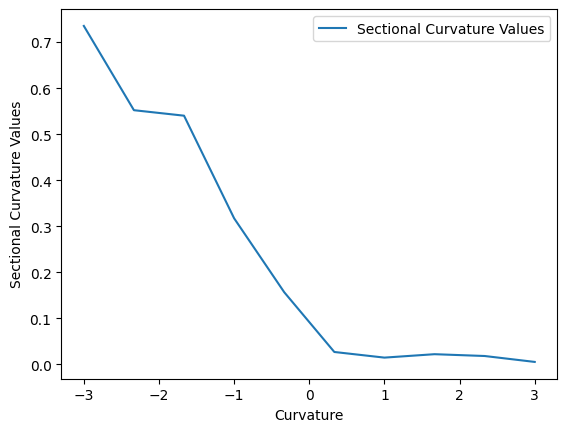

In [45]:
# Experiment 1: How does delta change with curvature?

import matplotlib.pyplot as plt
import numpy as np

# Thought: re-sampling different manifolds is gonna take a lot of time and also introduce stochasticity.
# Instead, we can use the exponenital map for a single sample.

# Ks = [-3.0, -2.5, -2.0, -1.5, -1.0, -0.5, 0.0]
Ks = np.linspace(-3.0, 3, 10).tolist()

# Get a single sample
N = torch.distributions.MultivariateNormal(loc=torch.zeros(DIMENSION), covariance_matrix=torch.eye(DIMENSION))

# Get a single sample and raise to tangent plane (prepend with zero)
x = N.sample(sample_shape=(N_SAMPLES,))
x_tangent = torch.hstack([torch.zeros(N_SAMPLES, 1), x])

all_sects = []
for K in Ks:
    print(f"Curvature: {K}")
    pm_K = ProductManifold(signature=[(K, DIMENSION)])

    # Get the exponential map
    if K == 0.0:
        x_exp = x
    else:
        x_exp = pm_K.expmap(x_tangent)

    # Get the distance
    dists = pm_K.pdist(x_exp)
    sect = sectional_curvature(dists)
    all_sects.append(sect)

plt.plot(Ks,all_sects, label="Sectional Curvature Values")
plt.xlabel('Curvature')
plt.ylabel('Sectional Curvature Values')
plt.legend()
plt.show()